# Análisis exploratorio de datos (EDA)

## 0. Estudio previo

En este cuaderno se trata el detalle de la multas de circulación del ayutamiento de Madrid utilizando como ejemplo los datos de **diciembre de 2024**. 

Inicialmente tenemos la referencia para la descarga del dataset en la url: https://datos.madrid.es/egob/catalogo/210104-395-multas-circulacion-detalle.csv, sin embargo la plataforma se ha migrado y los mismos datos también están disponibles en la nueva url: https://datos.madrid.es/dataset/210104-0-multas-circulacion-detalle/resource/210104-15-multas-circulacion-detalle-csv/download/210104-15-multas-circulacion-detalle-csv.csv.

![Multas de circulación: detalle 2024 diciembre](../assets/detalle-diciembre-2014.png)

Valido que los ficheros que podemos obtener a través de las dos url's sean iguales.

![Comparación de los ficheros descargados](../assets/compare-files.png)

Tanto `diff` como `cmp` muestran que el contenido de los dos ficheros es el mismo. Antes de cargar los datos en python voy a hacer una breve exploración de los ficheros, lo primero validar el **encoding**.

![Codificación de los ficheros](../assets/file-enconding.png)

No he podido extraer la información de la **codificación** de los ficheros, pero por el enunciado sé que se trata de una codificación `latin1`. Muestro una previsualización de las dos primeras filas *(cabecera y fila uno)* del dataset para ver algunos de los problemas que habrá que afrontar a la hora de trabajar con estos datos.

![Dos primeras filas del conjunto de datos](../assets/two-first-rows.png)

Lo más evidente en esta primera visualización es que tanto las cabeceras como los datos presentan varios espacios en blanco. 

Además la web del ayuntamiento de Madrid, nos ofrece un [pdf con el detalle del contenido y la estructura de los datos con los que vamos a trabajar](https://datos.madrid.es/dataset/210104-0-multas-circulacion-detalle/resource/210104-200-multas-circulacion-detalle/download/210104-200-multas-circulacion-detalle.pdf).

![Contenido y estructura de los ficheros](../assets/detalle-ficheros.png)

También podemos encontrar un fichero **[Resource Description Framework (RFD)](https://es.wikipedia.org/wiki/Resource_Description_Framework)** de metadatos que recoge la información de todos los recursos web de la página: https://datos.madrid.es/dataset/210104-0-multas-circulacion-detalle.rdf.

![Metadatos del conjuntos de datos](../assets/rdf.png)

## 1. Explorar la estructura de los datos en el dataframe

- El método `info` devuelve información acerca de la estructura de un dataframe. Ejecuta el método `info()` sobre el dataframe `multas` y comenta los resultados.
- Fíjate en las columnas que representan la hora, el mes y el año y observa su tipo de datos. ¿Cuántas filas se han cargado?. Fíjate en los valores distintos de `NaN` en cada una de las columnas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud


In [2]:
URL = "https://datos.madrid.es/dataset/210104-0-multas-circulacion-detalle/resource/210104-15-multas-circulacion-detalle-csv/download/210104-15-multas-circulacion-detalle-csv.csv"

multas = pd.read_csv(URL, sep=";", encoding="latin-1")

multas.head()


,CALIFICACION,LUGAR,MES,ANIO,HORA,IMP_BOL,DESCUENTO,PUNTOS,DENUNCIANTE,HECHO-BOL,VEL_LIMITE,VEL_CIRCULA,COORDENADA-X,COORDENADA-Y
0,LEVE,CL CLARA DEL REY 36,12,2024,20.23,60.0,SI,0,SER,ESTACIONAR CON AUTORIZACIÓN NO VÁLIDA. ...,,,,
1,LEVE,CL CLARA DEL REY 28,12,2024,20.27,90.0,SI,0,SER,"ESTACIONAR, SIN LA CORRESPONDIENTE AUTORIZACIÓ...",,,,
2,GRAVE,CL CANILLAS 63,12,2024,20.45,200.0,SI,0,SER,ESTACIONAR OBSTACULIZANDO LA UTILIZACIÓN DE UN...,,,,
3,LEVE,CL BRAVO MURILLO 24,12,2024,16.30,60.0,SI,0,SER,ESTACIONAR CON AUTORIZACIÓN NO VÁLIDA. ...,,,,
4,LEVE,CL BRAVO MURILLO 16,12,2024,16.50,90.0,SI,0,SER,"ESTACIONAR, SIN LA CORRESPONDIENTE AUTORIZACIÓ...",,,,


In [ ]:
# Funciones auxiliares para la exploración el dataset


def missing_data(data):
    """
    Extrae el número de valores nulos por columna, el porcentaje de valores nulos y el tipo de dato de cada columna.
    """
    total = data.isna().sum()
    percent = (data.isna().sum() / len(data)) * 100
    types = data.dtypes
    df = pd.concat(
        [total, percent, types], axis=1, keys=["Total", "Porcentaje", "Tipo"]
    )
    return df.transpose()


def most_frequent_values(data):
    """
    Valores más frecuentes por columna, su frecuencia y el porcentaje que representan del total de valores no nulos.
    """
    # Total por columna de los valores no NaN
    # Ver: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.count.html#pandas.DataFrame.count
    total = data.count()
    df = pd.DataFrame(total, columns=["Total"])
    items = []
    values = []
    for col in data.columns:
        try:
            item = data[col].value_counts().index[0]
            value = data[col].value_counts().values[0]
            items.append(item)
            values.append(value)
        except Exception as ex:
            print(f"Error en la columna {col}: {ex}")
            item.append(0)
            values.append(0)
            continue
    df["Valor más frecuente"] = items
    df["Frecuencia"] = values
    df["Porcentaje del total"] = np.round(df["Frecuencia"] / df["Total"] * 100, 3)
    return df.transpose()


def unique_values(data):
    """
    Valores únicos por columna y su frecuencia.
    """
    total = data.count()
    df = pd.DataFrame(total, columns=["Total"])
    uniques = []
    for col in data.columns:
        uniques.append(data[col].nunique())
    df["Valores únicos"] = uniques
    return df.transpose()


In [4]:
multas.info()


<class 'pandas.DataFrame'>
RangeIndex: 249801 entries, 0 to 249800
Data columns (total 14 columns):
 #   Column                                                                                                                                                  Non-Null Count   Dtype  
---  ------                                                                                                                                                  --------------   -----  
 0   CALIFICACION                                                                                                                                            249801 non-null  str    
 1   LUGAR                                                                                                                                                   249801 non-null  str    
 2   MES                                                                                                                                                     249801 non-null

In [5]:
missing_data(multas)


,CALIFICACION,LUGAR,MES,ANIO,HORA,IMP_BOL,DESCUENTO,PUNTOS,DENUNCIANTE,HECHO-BOL,VEL_LIMITE,VEL_CIRCULA,COORDENADA-X,COORDENADA-Y
Total,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Porcentaje,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Tipo,str,str,int64,int64,float64,float64,str,int64,str,str,str,str,str,str


In [6]:
most_frequent_values(multas)


,CALIFICACION,LUGAR,MES,ANIO,HORA,IMP_BOL,DESCUENTO,PUNTOS,DENUNCIANTE,HECHO-BOL,VEL_LIMITE,VEL_CIRCULA,COORDENADA-X,COORDENADA-Y
Total,249801,249801,249801,249801,249801,249801,249801,249801,249801,249801,249801,249801,249801,249801
Valor más frecuente,GRAVE,CALLE ALCALA 51,12,2024,10.0,200.0,SI,0,MEDIOS DE CAPTACION DE IMAGEN,NO RESPETAR LAS RESTRICCIONES DE CIRCULACIÓN D...,,,,
Frecuencia,157605,7440,249801,249801,427,130984,249801,238628,119981,60650,227619,227619,125919,125919
Porcentaje del total,63.092,2.978,100.0,100.0,0.171,52.435,100.0,95.527,48.031,24.279,91.12,91.12,50.408,50.408


In [7]:
unique_values(multas)


,CALIFICACION,LUGAR,MES,ANIO,HORA,IMP_BOL,DESCUENTO,PUNTOS,DENUNCIANTE,HECHO-BOL,VEL_LIMITE,VEL_CIRCULA,COORDENADA-X,COORDENADA-Y
Total,249801,249801,249801,249801,249801,249801,249801,249801,249801,249801,249801,249801,249801,249801
Valores únicos,3,34647,1,1,1440,11,1,6,6,345,7,101,2455,2500


In [8]:
print(f"El dataframe multas contiene contiene: {multas.shape[0]:,} registros.")
print("Los tipos de las columnas «año, mes y horas» son:")
for label, col in zip(("año", "mes", "hora"), ("ANIO", "MES", "HORA")):
    print(f"  - {label:>4}: {multas[col].dtype}")


El dataframe multas contiene contiene: 249,801 registros.
Los tipos de las columnas «año, mes y horas» son:
  -  año: int64
  -  mes: int64
  - hora: float64


No existen valores **NaN** en ninguna de las columnas, esto es debido a como `pandas` está parseando los datos. Cuando visualizamos las primeras filas del dataframe se observa claramente como las columnas: `VEL_LIMITE`, `VEL_CIRCULA`,  `COORDENADA-X` y `COORDENADA-Y` aparecen vacías y al observar su tipo vemos que se consideran de tipo `str`. `Pandas` esta parseando estas columnas como `strings` e interpreta los registros vacíos como cadenas de caracteres vacías y no como **NaN**. Para todas estás columnas el valor más frecuente es el del registro vacío con alrededor de un **91%** en el caso de `VEL_LIMITE` y `VEL_CIRCULA` y de un **50%** en el caso de `COORDENADA-X` y `COORDENADA-Y`.


**NOTA:**

La primera versión de este cuaderno la ejecutaba en `google colab` y las columnas `VEL_LIMITE`, `VEL_CIRCULA`,  `COORDENADA-X` y `COORDENADA-Y` se consideraban de tipo `object`, depende de la versión de `pandas`, este cuaderno usa una versión más moderna de y se parsean como `str`. Lo importante, es saber que en ningún caso las columnas se van a parsear como número de forma implícita (ya que están mezclando varios tipos de datos) y por tanto los registros con espacios vacíos no se tratan como **NaN**.

In [9]:
df = multas["VEL_LIMITE"].value_counts().reset_index(drop=False)
df["len"] = df["VEL_LIMITE"].str.len()
df[["VEL_LIMITE", "len", "count"]]


,VEL_LIMITE,len,count
0,,3,227619
1,70,3,10235
2,50,3,5153
3,90,3,4261
4,60,3,1758
5,40,3,767
6,30,3,8


Haciendo foco en una de las columnas, `VEL_LIMITE`, vemos que todos los registros vacíos tienen la misma longitud 3 espacios en blanco.

## 2. Exploración de las columnas

### **a)** ¿Cuántos valores distintos hay en la columna `CALIFICACION` del dataframe `multas`? Modifica los valores de dicha columna para que no contengan espacios en blanco. Puedes usar el método  `str.strip()` de la clase Series.

In [10]:
multas["CALIFICACION"].value_counts()


CALIFICACION
GRAVE         157605
LEVE           91388
MUY GRAVE        808
Name: count, dtype: int64

Existen 3 valores distintos en la columna `CALIFICACION`. 


In [11]:
multas["CALIFICACION"].str.len().value_counts()


CALIFICACION
10    249801
Name: count, dtype: int64

Una constante que nos encontramos a los largo de todo este dataset, es que el logitud de todos los campos de tipo `str` es la misma, esto se debe a que las cadenas de carácteres más pequeñas se completan con espacios en blanco.

In [12]:
for col in multas.columns:
    if multas[col].dtype == "str" and col != "CALIFICACION":
        print(f"Columna: {col}")
        print(multas[col].str.len().value_counts(), end="\n\n")


Columna: LUGAR
LUGAR
40    249801
Name: count, dtype: int64

Columna: DESCUENTO
DESCUENTO
2    249801
Name: count, dtype: int64

Columna: DENUNCIANTE
DENUNCIANTE
30    249801
Name: count, dtype: int64

Columna: HECHO-BOL
HECHO-BOL
125    249801
Name: count, dtype: int64

Columna: VEL_LIMITE
VEL_LIMITE
3    249801
Name: count, dtype: int64

Columna: VEL_CIRCULA 
VEL_CIRCULA 
3    249801
Name: count, dtype: int64

Columna: COORDENADA-X
COORDENADA-X
11    249801
Name: count, dtype: int64

Columna: COORDENADA-Y                                                                                                                                          
COORDENADA-Y                                                                                                                                          
11    249801
Name: count, dtype: int64



In [ ]:
multas["CALIFICACION"] = multas["CALIFICACION"].str.strip()


In [15]:
multas["CALIFICACION"].str.len().value_counts()


CALIFICACION
5    157605
4     91388
9       808
Name: count, dtype: int64

### **b)** ¿Cuántos valores distintos hay en las columnas `DESCUENTO`, `HECHO-BOL` y `DENUNCIANTE` del dataframe `multas`? Modifica los valores de dichas columnas para que no contengan espacios en blanco.

In [17]:
unique_values(multas[["LUGAR", "DESCUENTO", "HECHO-BOL", "DENUNCIANTE"]])


,LUGAR,DESCUENTO,HECHO-BOL,DENUNCIANTE
Total,249801,249801,249801,249801
Valores únicos,34647,1,345,6


In [ ]:
# También limpio los espacios de la columna LUGAR que presenta el mismo problema
for col in ["LUGAR", "DESCUENTO", "HECHO-BOL", "DENUNCIANTE"]:
    multas[col] = multas[col].str.strip()


### **c)** Muestra el listado de columnas del dataframe.
- ¿Cuál es el nombre de la columna que representa la velocidad de circulación registrada? Fíjate en el espacio en blanco al final.
- ¿Cuál es el nombre de la columna que representa la coordenada Y de la ubicación geográfica de donde se produce la infracción? Fíjate en la cantidad de espacios en blanco al final.
- Muestra la serie de datos correspondiente a la coordenada Y.
- Usa el método  `rename` de los dataframes para normalizar los nombres de las columnas del dataframe multas, de forma que los nuevos nombres no tengan espacios en blanco al final. Consulta la ayuda del método `rename`; ésta te propone el uso de métodos de la clase `str` a cada elemento del índice de las columnas (o de las filas). En nuestro caso, para eliminar espacios en blanco usaremos el método `str.strip()` sobre el índice de las columnas.

In [19]:
for col in multas.columns:
    print(repr(col))


'CALIFICACION'
'LUGAR'
'MES'
'ANIO'
'HORA'
'IMP_BOL'
'DESCUENTO'
' PUNTOS'
'DENUNCIANTE'
'HECHO-BOL'
'VEL_LIMITE'
'VEL_CIRCULA '
'COORDENADA-X'
'COORDENADA-Y                                                                                                                                          '


- ¿Cuál es el nombre de la columna que representa la velocidad de circulación registrada? Fíjate en el espacio en blanco al final.

    La columna `VEL_CIRCULA` representa la velocidad de circulación y podemos comprobar que tiene un espacio en blanco final.

- ¿Cuál es el nombre de la columna que representa la coordenada Y de la ubicación geográfica de donde se produce la infracción? Fíjate en la cantidad de espacios en blanco al final.

    La columna `COORDENADA-Y` que contiene varios espacios en blanco al final.


**Nota:**

La columna `PUNTOS` también contiene un espacio en blanco al principio.

In [20]:
def normalize_columns(data):
    """
    Función auxiliar para normalizar los nombres de las columnas.
    """
    return data.strip().upper().replace("-", "_").replace(" ", "_")


multas = multas.rename(columns=normalize_columns)
multas.columns


Index(['CALIFICACION', 'LUGAR', 'MES', 'ANIO', 'HORA', 'IMP_BOL', 'DESCUENTO',
       'PUNTOS', 'DENUNCIANTE', 'HECHO_BOL', 'VEL_LIMITE', 'VEL_CIRCULA',
       'COORDENADA_X', 'COORDENADA_Y'],
      dtype='str')

### **d)** ¿Observa las columnas relativas a la velocidad. 
- ¿De qué tipo son?. 
- ¿Cuántos valores distintos hay en las columnas `VEL_LIMITE`, `VEL_CIRCULA`. Por último, estudia la función `pd.to_numeric` de pandas y úsala para transformar el tipo de las columnas  anteriores a tipo numérico.

In [21]:
missing_data(multas[["VEL_LIMITE", "VEL_CIRCULA"]])


,VEL_LIMITE,VEL_CIRCULA
Total,0,0
Porcentaje,0.0,0.0
Tipo,str,str


In [22]:
unique_values(multas[["VEL_LIMITE", "VEL_CIRCULA"]])


,VEL_LIMITE,VEL_CIRCULA
Total,249801,249801
Valores únicos,7,101


In [23]:
multas["VEL_LIMITE"] = pd.to_numeric(multas["VEL_LIMITE"], errors="coerce")
multas["VEL_CIRCULA"] = pd.to_numeric(multas["VEL_CIRCULA"], errors="coerce")

missing_data(multas[["VEL_LIMITE", "VEL_CIRCULA"]])


,VEL_LIMITE,VEL_CIRCULA
Total,227619,227619
Porcentaje,91.120132,91.120132
Tipo,float64,float64


In [24]:
# Existe un valor único menos en ambas columnas que corresponde a los valores de espacios en blanco que se han convertido a NaN al convertir a numérico.
unique_values(multas[["VEL_LIMITE", "VEL_CIRCULA"]])


,VEL_LIMITE,VEL_CIRCULA
Total,22182,22182
Valores únicos,6,100


In [25]:
# Valor no nulo más frecuente en cada columna y su frecuencia
most_frequent_values(multas[["VEL_LIMITE", "VEL_CIRCULA"]])


,VEL_LIMITE,VEL_CIRCULA
Total,22182.000,22182.000
Valor más frecuente,70.000,74.000
Frecuencia,10235.000,1903.000
Porcentaje del total,46.141,8.579


### **e)** ¿Observa las columnas relativas a la geolocalización. 
- ¿De qué tipo son?. Usa la función `pd.to_numeric` de pandas para transformar el tipo de las columnas  `COORDENADA-X`, `COORDENADA-Y` a tipo numérico.

In [26]:
missing_data(multas[["COORDENADA_X", "COORDENADA_Y"]])


,COORDENADA_X,COORDENADA_Y
Total,0,0
Porcentaje,0.0,0.0
Tipo,str,str


In [ ]:
multas["COORDENADA_X"] = pd.to_numeric(multas["COORDENADA_X"], errors="coerce")
multas["COORDENADA_Y"] = pd.to_numeric(multas["COORDENADA_Y"], errors="coerce")


In [28]:
missing_data(multas[["COORDENADA_X", "COORDENADA_Y"]])


,COORDENADA_X,COORDENADA_Y
Total,125919,125919
Porcentaje,50.407725,50.407725
Tipo,float64,float64


In [29]:
most_frequent_values(multas[["COORDENADA_X", "COORDENADA_Y"]])


,COORDENADA_X,COORDENADA_Y
Total,123882.000,123882.000
Valor más frecuente,441089.560,4474540.000
Frecuencia,7440.000,7440.000
Porcentaje del total,6.006,6.006


In [31]:
# Comprobar que las coordenadas X e Y más frecuentes corresponden al mismo punto geográfico
multas.loc[
    multas["COORDENADA_X"] == 441089.560, ["LUGAR", "COORDENADA_X", "COORDENADA_Y"]
]


,LUGAR,COORDENADA_X,COORDENADA_Y
87971,CALLE ALCALA 51,441089.56,4474540.0
87973,CALLE ALCALA 51,441089.56,4474540.0
87994,CALLE ALCALA 51,441089.56,4474540.0
87997,CALLE ALCALA 51,441089.56,4474540.0
87999,CALLE ALCALA 51,441089.56,4474540.0
...,...,...,...
198109,CALLE ALCALA 51,441089.56,4474540.0
198115,CALLE ALCALA 51,441089.56,4474540.0
198136,CALLE ALCALA 51,441089.56,4474540.0
198158,CALLE ALCALA 51,441089.56,4474540.0


Las coordenadas **(441089.56, 4474540.00)** aparecen como los valores más frecuentes de los puntos que han sido geolozalizados, es un punto geográfico, según la información de la web del ayuntamiento de Madrid:

> Los ficheros, a partir de marzo 2016 (incluído), presentan dos columnas adicionales, como mejora de la información, con campos que faciliten la georreferenciación *(Coordenada-X; Coordenada-Y, en sistema de referencia ETRS89)*.

Se puede utilizar alguna calculadora geodesica para convertir los datos a **latitud, longitud**:

![Conversión a latitud, longitud](../assets/calculadora-geodesica.png)

Obtenemos que el puntos más conflitivo de los que se están geolocalizando es: https://www.google.com/maps/place/40%C2%B025'09.9%22N+3%C2%B041'39.9%22W/@40.419407,-3.6969881,17z/data=!3m1!4b1!4m4!3m3!8m2!3d40.4194029!4d-3.6944078?entry=ttu&g_ep=EgoyMDI2MDMyNC4wIKXMDSoASAFQAw%3D%3D, que efectivamente se trata de **calle Alcalá 51**, valor que registra la columna **LUGAR** para estas coordenadas.

![Coordenadas en google maps](../assets/coordenadas.png)

## 3. Creación de columna nueva


### **a)** A partir del dataframe `multas` que contiene las columnas `MES`, `ANIO` y `HORA`, crear una nueva columna llamada `fecha` de tipo datetime que combine dicha información en un único objeto de fecha y hora. Usa como día el día 1.

**IMPORTANTE!!!** Un detalle a tener en cuenta es que la columna **"HORAS"** almanacena hora y minutos, el decimal no representa una fracción de hora, sino que representa los minutos. Por ejemplo, el valor 14.30 representa las 14 horas y 30 minutos, no las 14 horas y 0.3 horas (18 minutos). Esto es importante tenerlo en cuenta para evitar confusiones al interpretar los datos de la columna **"HORAS"**.

In [32]:
multas["fecha"] = pd.to_datetime(
    multas["ANIO"].astype(str)
    + "-"
    + multas["MES"].astype(str)
    + "-01 "
    + multas["HORA"].map(lambda x: f"{int(x):02d}:{int(round(x % 1 * 100)):02d}"),
    format="%Y-%m-%d %H:%M",
)

multas[["ANIO", "MES", "HORA", "fecha"]].head()


,ANIO,MES,HORA,fecha
0,2024,12,20.23,2024-12-01 20:23:00
1,2024,12,20.27,2024-12-01 20:27:00
2,2024,12,20.45,2024-12-01 20:45:00
3,2024,12,16.30,2024-12-01 16:30:00
4,2024,12,16.50,2024-12-01 16:50:00


### **b)** Modifica el dataframe `multas` de forma que el índice sea el valor de la columna creada anteriormente.

### **c)** Elimina del dataframe la columna `fecha`.


In [33]:
multas = multas.set_index("fecha", drop=True)
multas.head()


,CALIFICACION,LUGAR,MES,ANIO,HORA,IMP_BOL,DESCUENTO,PUNTOS,DENUNCIANTE,HECHO_BOL,VEL_LIMITE,VEL_CIRCULA,COORDENADA_X,COORDENADA_Y
fecha,,,,,,,,,,,,,,
2024-12-01 20:23:00,LEVE,CL CLARA DEL REY 36,12,2024,20.23,60.0,SI,0,SER,ESTACIONAR CON AUTORIZACIÓN NO VÁLIDA.,NaN,NaN,NaN,NaN
2024-12-01 20:27:00,LEVE,CL CLARA DEL REY 28,12,2024,20.27,90.0,SI,0,SER,"ESTACIONAR, SIN LA CORRESPONDIENTE AUTORIZACIÓ...",NaN,NaN,NaN,NaN
2024-12-01 20:45:00,GRAVE,CL CANILLAS 63,12,2024,20.45,200.0,SI,0,SER,ESTACIONAR OBSTACULIZANDO LA UTILIZACIÓN DE UN...,NaN,NaN,NaN,NaN
2024-12-01 16:30:00,LEVE,CL BRAVO MURILLO 24,12,2024,16.30,60.0,SI,0,SER,ESTACIONAR CON AUTORIZACIÓN NO VÁLIDA.,NaN,NaN,NaN,NaN
2024-12-01 16:50:00,LEVE,CL BRAVO MURILLO 16,12,2024,16.50,90.0,SI,0,SER,"ESTACIONAR, SIN LA CORRESPONDIENTE AUTORIZACIÓ...",NaN,NaN,NaN,NaN


---

## 4. Visualizando los datos

Se incluyen algunas visualizaciones que ayuden al entendimiento del dataset y se explora la resolución de los automatizaciones que plantea el ejercicio en la clase `MadridFines`.

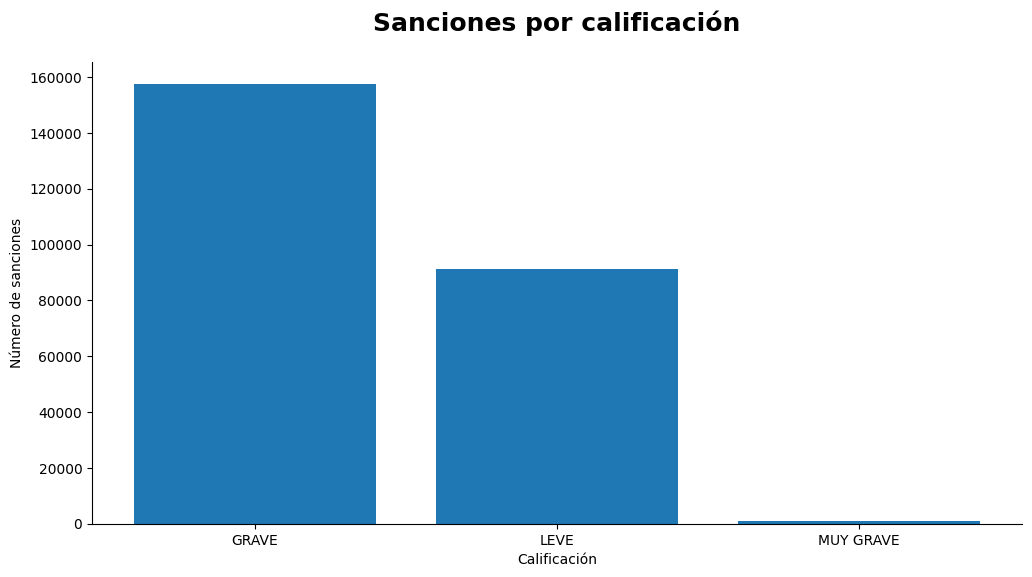

In [34]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

calificacion = multas["CALIFICACION"].value_counts()
ax.bar(calificacion.index, calificacion.values)
ax.set_title("Sanciones por calificación", fontsize=18, fontweight="bold", y=1.05)
ax.set_xlabel("Calificación")
ax.set_ylabel("Número de sanciones")

ax.spines[["top", "right"]].set_visible(False)

plt.show()


In [38]:
sanciones_yearmonth_hour = (
    multas.groupby(
        [
            multas.index.hour.rename("Hour"),
            multas.index.to_period("M").rename("YearMonth"),
        ]
    )
    .size()
    .unstack(level=-1, fill_value=0)
)

sanciones_yearmonth_hour.head()


YearMonth,2024-12
Hour,
0,4697
1,2983
2,1801
3,1342
4,1281


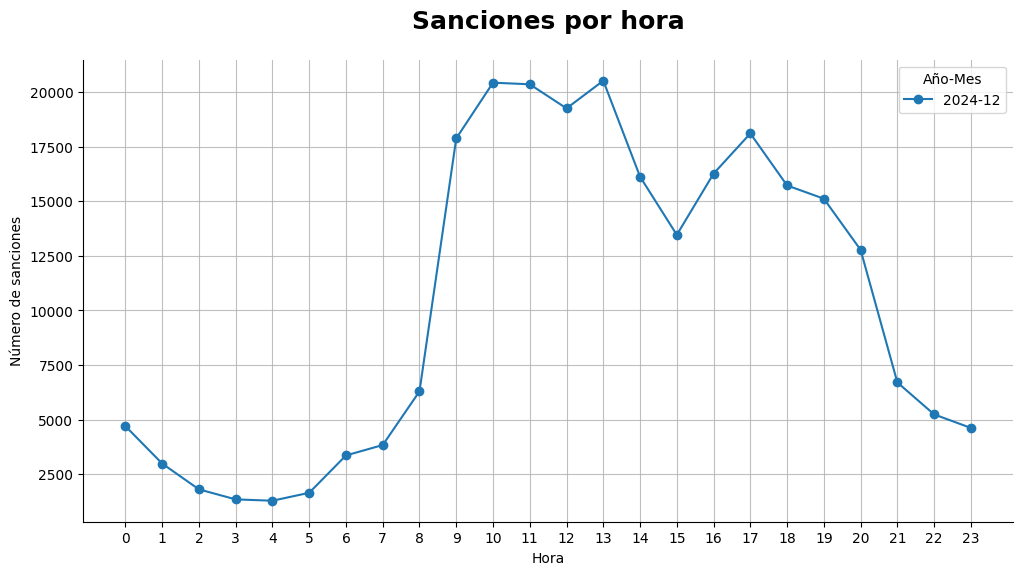

In [43]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

for yearmonth in sanciones_yearmonth_hour.columns:
    ax.plot(
        sanciones_yearmonth_hour.index,
        sanciones_yearmonth_hour[yearmonth],
        marker="o",
        label=yearmonth,
    )

ax.set_title("Sanciones por hora", fontsize=18, fontweight="bold", y=1.05)

ax.set_xticks(sanciones_yearmonth_hour.index)
ax.set_xlabel("Hora")
ax.set_ylabel("Número de sanciones")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.8)

ax.legend(title="Año-Mes")

plt.show()


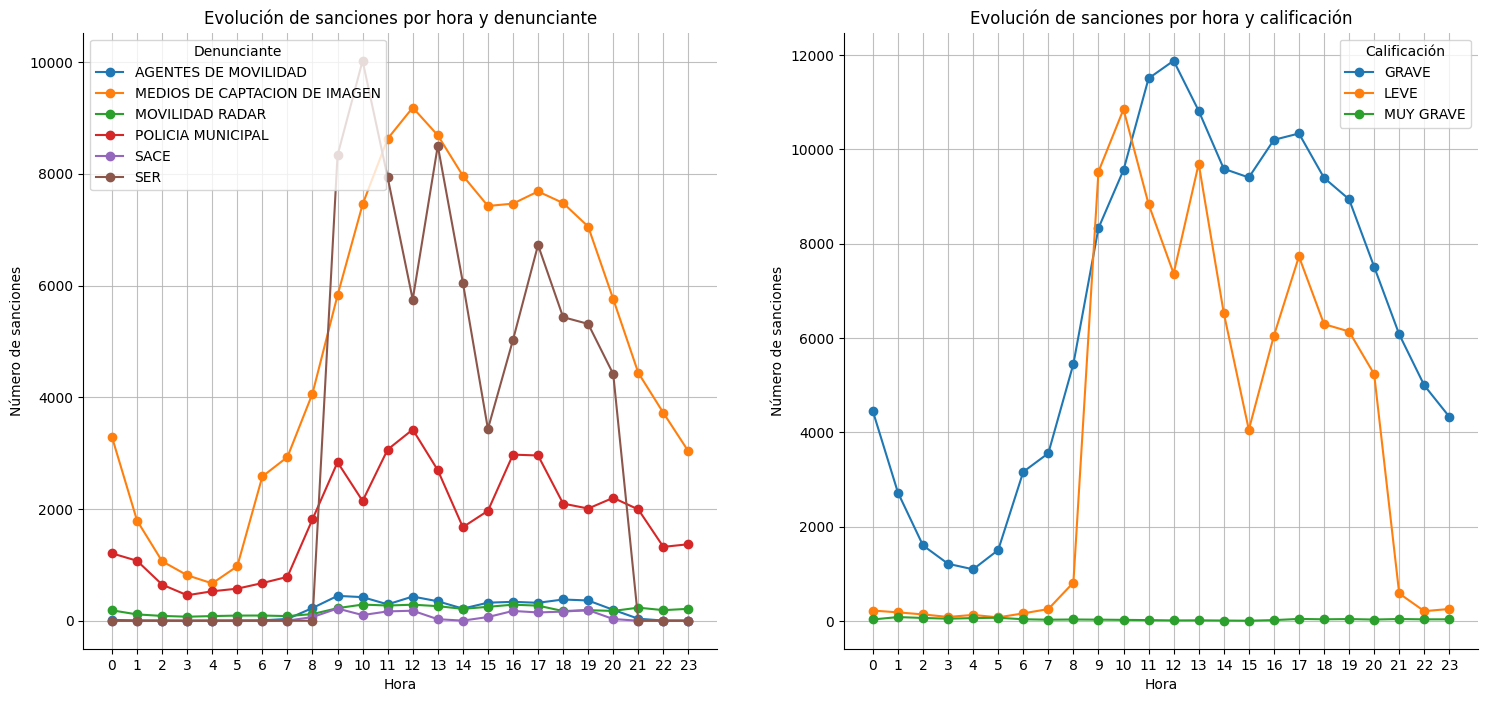

In [44]:
hora_denunciante = (
    multas.groupby(
        [multas.index.hour.rename("Hora"), multas["DENUNCIANTE"].rename("Denunciante")]
    )
    .size()
    .unstack(level=-1, fill_value=0)
)

hora_calificacion = (
    multas.groupby(
        [
            multas.index.hour.rename("Hora"),
            multas["CALIFICACION"].rename("Calificacion"),
        ]
    )
    .size()
    .unstack(level=-1, fill_value=0)
)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), dpi=100)

# Sanciones por hora y denunciante
for denunciante in hora_denunciante.columns:
    ax1.plot(
        hora_denunciante.index,
        hora_denunciante[denunciante],
        marker="o",
        label=denunciante,
    )

ax1.set_title(
    "Evolución de sanciones por hora y denunciante",
)

ax1.set_xticks(hora_denunciante.index)
ax1.set_xlabel("Hora")
ax1.set_ylabel("Número de sanciones")

ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(alpha=0.8)

ax1.legend(title="Denunciante", loc="upper left")

# Sanciones por hora y calificación
for calificacion in hora_calificacion.columns:
    ax2.plot(
        hora_calificacion.index,
        hora_calificacion[calificacion],
        marker="o",
        label=calificacion,
    )

ax2.set_title(
    "Evolución de sanciones por hora y calificación",
)

ax2.set_xticks(hora_calificacion.index)
ax2.set_xlabel("Hora")
ax2.set_ylabel("Número de sanciones")

ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(alpha=0.8)

ax2.legend(title="Calificación", loc="upper right")

plt.show()


In [45]:
# Distribución de multas por calificación, mes y año
multas.groupby(
    [
        multas["MES"].rename("Mes"),
        multas["ANIO"].rename("Año"),
        multas["CALIFICACION"].rename("Calificación"),
    ]
).size().unstack(-1)


,Calificación,GRAVE,LEVE,MUY GRAVE
Mes,Año,,,
12,2024,157605,91388,808


In [53]:
# Importe máximo y mínimo recaudado por mes y año
# Ver: https://pandas.pydata.org/docs/user_guide/groupby.html#groupby-aggregate-named
df = multas.copy()
df["IMP_DESCUENTO"] = np.where(
    df["DESCUENTO"] == "SI", df["IMP_BOL"] / 2, df["IMP_BOL"]
)

df.groupby(
    [
        df.index.month.rename("Mes"),
        df.index.year.rename("Año"),
    ]
).agg(
    minimo=pd.NamedAgg(column="IMP_DESCUENTO", aggfunc="sum"),
    maximo=pd.NamedAgg(column="IMP_BOL", aggfunc="sum"),
)


,,minimo,maximo
Mes,Año,,
12,2024,18502615.0,37005230.0


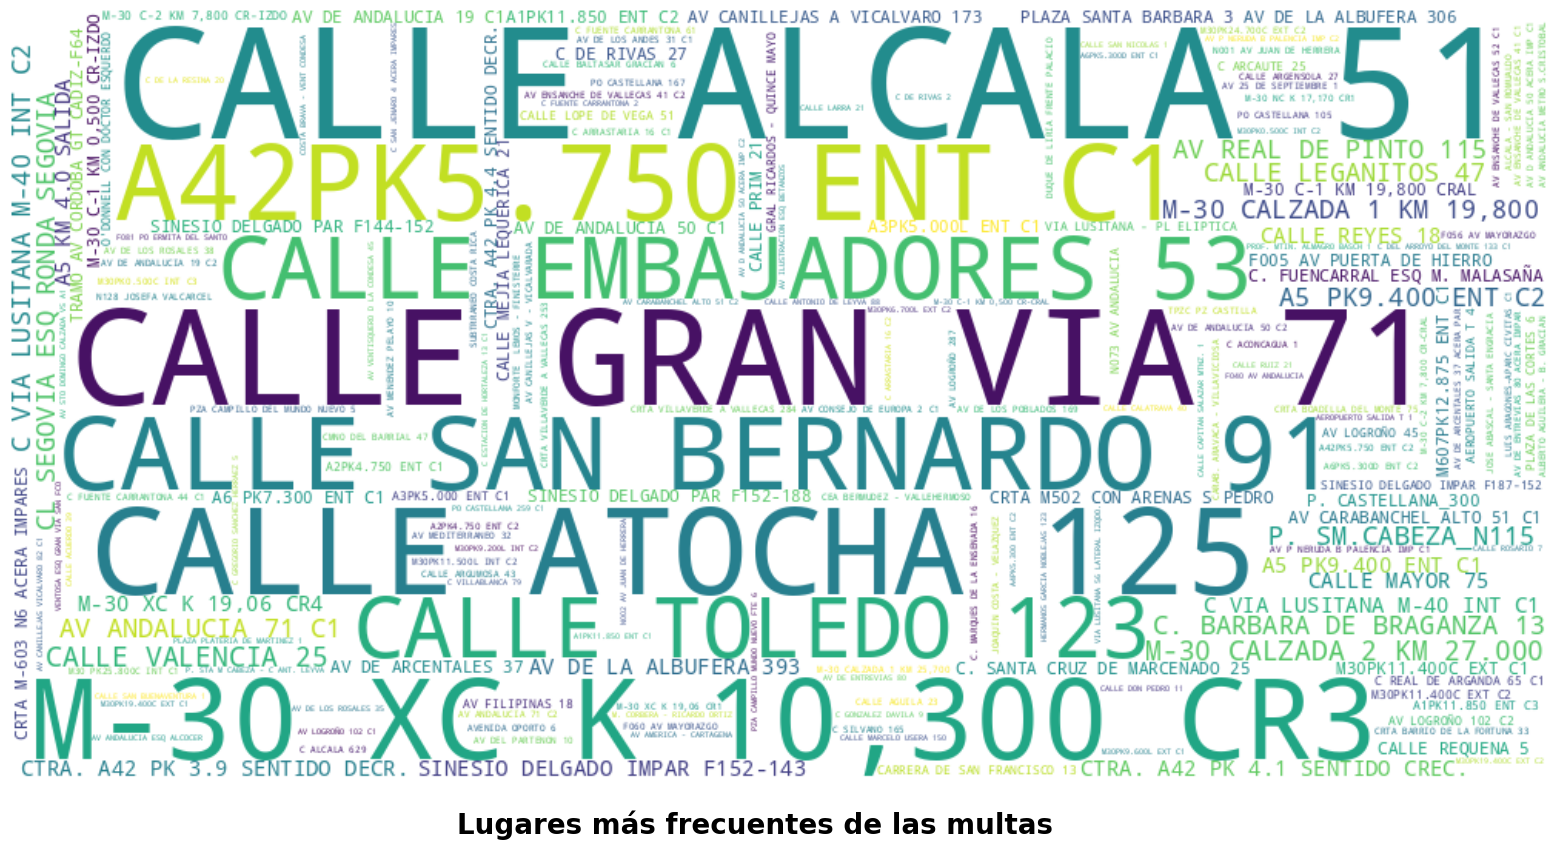

In [49]:
freq = multas["LUGAR"].value_counts().head(200)

wordcloud = WordCloud(
    width=1000, height=500, background_color="white"
).generate_from_frequencies(freq)

fig, ax = plt.subplots(1, 1, figsize=(20, 10), dpi=100)
fig.suptitle(
    "Lugares más frecuentes de las multas", fontsize=20, fontweight="bold", y=0.08
)
ax.imshow(wordcloud, interpolation="bilinear")
ax.axis("off")
plt.show()


[@title]: #
[Source - https://stackoverflow.com/a/35760941]: #
[Posted by Harmon, modified by community. See post 'Timeline' for change history]: #
[Retrieved 2026-02-26, License - CC BY-SA 4.0]: #

<style>
    footer {
    width: 100%;
    display: flex;
    justify-content: center;
    margin: 3rem 0;

    & a svg {
      position: relative;
      top: 4px;
      height: 1.25em;
    }
  }
</style>
<footer>
    <a href="https://alejandrodecora.es/til">
        Hecho con 💜 por
        <!-- prettier-ignore -->
        <svg viewBox="0 0 600 530" version="1.1" xmlns="http://www.w3.org/2000/svg">
        <path
          d="m135.72 44.03c66.496 49.921 138.02 151.14 164.28 205.46 26.262-54.316 97.782-155.54 164.28-205.46 47.98-36.021 125.72-63.892 125.72 24.795 0 17.712-10.155 148.79-16.111 170.07-20.703 73.984-96.144 92.854-163.25 81.433 117.3 19.964 147.14 86.092 82.697 152.22-122.39 125.59-175.91-31.511-189.63-71.766-2.514-7.3797-3.6904-10.832-3.7077-7.8964-0.0174-2.9357-1.1937 0.51669-3.7077 7.8964-13.714 40.255-67.233 197.36-189.63 71.766-64.444-66.128-34.605-132.26 82.697-152.22-67.108 11.421-142.55-7.4491-163.25-81.433-5.9562-21.282-16.111-152.36-16.111-170.07 0-88.687 77.742-60.816 125.72-24.795z"
          fill="#1185fe" />
        </svg>
        <code>@vichelocrego</code>
    </a>
</footer>